In [1]:
# ============================================
# EDA - Denuncias Policiales (SIDPOL) 2018-2025
# Paso 0-1: Carga + limpieza mínima + checks + primeros gráficos
# ============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 0) Config general
# -----------------------------
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

OUT_DIR = "outputs"
FIG_DIR = os.path.join(OUT_DIR, "figures")
TAB_DIR = os.path.join(OUT_DIR, "tables")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

def save_fig(name: str):
    path = os.path.join(FIG_DIR, name)
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.close()
    return path

def save_table(df: pd.DataFrame, name: str):
    path = os.path.join(TAB_DIR, name)
    df.to_csv(path, index=False, encoding="utf-8-sig")
    return path

# -----------------------------
# 1) Cargar dataset
# -----------------------------
# Opción A: Descarga directa (si te funciona)
URL_CSV = "https://www.datosabiertos.gob.pe/sites/default/files/DATASET_Denuncias_Policiales_Ene%202018%20a%20Nov%202025.csv"

# Opción B: si ya lo descargaste manualmente, coloca la ruta local:
LOCAL_CSV = None  # Ejemplo: r"D:\EDA_SIDPOL\DATASET_Denuncias_Policiales.csv"

def load_data():
    if LOCAL_CSV and os.path.exists(LOCAL_CSV):
        print("Leyendo desde archivo local:", LOCAL_CSV)
        return pd.read_csv(LOCAL_CSV, low_memory=False)
    print("Intentando leer desde URL:", URL_CSV)
    return pd.read_csv(URL_CSV, low_memory=False)

df = load_data()
print("Shape:", df.shape)
display(df.head())

# -----------------------------
# 2) Normalizar nombres de columnas
# -----------------------------
df.columns = [c.strip().upper() for c in df.columns]

# Mapeo esperado (según tu resumen)
# ANIO, MES, DPTO_HECHO_NEW, PROV_HECHO, DIST_HECHO, UBIGEO_HECHO, P_MODALIDADES, CANTIDAD
print("Columnas:", df.columns.tolist())

# -----------------------------
# 3) Tipado básico + limpieza mínima
# -----------------------------
# Asegurar numéricos (si vienen como texto)
for col in ["ANIO", "MES", "CANTIDAD"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Normalizar texto (categóricas)
cat_cols = ["DPTO_HECHO_NEW", "PROV_HECHO", "DIST_HECHO", "P_MODALIDADES", "UBIGEO_HECHO"]
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        df.loc[df[col].isin(["nan", "NaN", "None", ""]), col] = np.nan

# Chequeo rápido de rangos esperados
if "MES" in df.columns:
    print("Meses únicos (muestra):", sorted(df["MES"].dropna().unique())[:20])

# -----------------------------
# 4) Completitud (missing / nulos)
# -----------------------------
missing = (df.isna().mean() * 100).sort_values(ascending=False).to_frame("missing_%")
missing["missing_n"] = df.isna().sum()
missing = missing.reset_index().rename(columns={"index": "columna"})
display(missing)

save_table(missing, "01_missing_por_columna.csv")

# -----------------------------
# 5) Duplicados (en dataset agregado)
# -----------------------------
# En agregado, lo lógico es que una fila sea única por:
# (ANIO, MES, DPTO, PROV, DIST, UBIGEO, MODALIDAD)
key_cols = [c for c in ["ANIO","MES","DPTO_HECHO_NEW","PROV_HECHO","DIST_HECHO","UBIGEO_HECHO","P_MODALIDADES"] if c in df.columns]
if len(key_cols) >= 3:
    dup_n = df.duplicated(subset=key_cols).sum()
    print("Duplicados por clave agregada:", dup_n)

# -----------------------------
# 6) Medidas descriptivas (solo sobre CANTIDAD)
# -----------------------------
# Nota: como el dataset es agregado, la variable numérica principal es CANTIDAD.
x = df["CANTIDAD"].dropna()

desc = pd.DataFrame({
    "n": [x.size],
    "min": [x.min()],
    "p25": [x.quantile(0.25)],
    "mediana": [x.median()],
    "media": [x.mean()],
    "p75": [x.quantile(0.75)],
    "max": [x.max()],
    "varianza": [x.var()],
    "std": [x.std()],
    "cv": [x.std()/x.mean() if x.mean()!=0 else np.nan],
    "asimetria": [x.skew()],      # forma
    "curtosis": [x.kurt()]        # forma (exceso)
})
display(desc)
save_table(desc, "02_descriptivas_cantidad.csv")

# Histograma (distribución)
plt.figure()
plt.hist(x, bins=50)
plt.title("Distribución de CANTIDAD (conteos agregados)")
plt.xlabel("CANTIDAD")
plt.ylabel("Frecuencia")
save_fig("03_hist_cantidad.png")

# Boxplot (outliers preliminar)
plt.figure()
plt.boxplot(x, vert=True)
plt.title("Boxplot de CANTIDAD (detección preliminar de outliers)")
plt.ylabel("CANTIDAD")
save_fig("04_boxplot_cantidad.png")

# -----------------------------
# 7) Resumen univariado clave (Top categorías)
# -----------------------------
def top_n(col, n=15):
    if col not in df.columns:
        return None
    t = (df.groupby(col)["CANTIDAD"].sum()
           .sort_values(ascending=False)
           .head(n)
           .reset_index())
    return t

top_modal = top_n("P_MODALIDADES", 15)
if top_modal is not None:
    display(top_modal)
    save_table(top_modal, "05_top15_modalidades_por_denuncias.csv")

    plt.figure()
    plt.barh(top_modal["P_MODALIDADES"].astype(str), top_modal["CANTIDAD"])
    plt.title("Top 15 modalidades (suma de denuncias)")
    plt.xlabel("Denuncias (suma de CANTIDAD)")
    plt.gca().invert_yaxis()
    save_fig("06_barh_top15_modalidades.png")

top_dpto = top_n("DPTO_HECHO_NEW", 15)
if top_dpto is not None:
    display(top_dpto)
    save_table(top_dpto, "07_top15_departamentos_por_denuncias.csv")

    plt.figure()
    plt.barh(top_dpto["DPTO_HECHO_NEW"].astype(str), top_dpto["CANTIDAD"])
    plt.title("Top 15 departamentos (suma de denuncias)")
    plt.xlabel("Denuncias (suma de CANTIDAD)")
    plt.gca().invert_yaxis()
    save_fig("08_barh_top15_departamentos.png")

# -----------------------------
# 8) Tendencia temporal (global) - serie por año/mes
# -----------------------------
if "ANIO" in df.columns and "MES" in df.columns:
    ts = (df.groupby(["ANIO","MES"])["CANTIDAD"].sum()
            .reset_index()
            .sort_values(["ANIO","MES"]))

    # Crear fecha aproximada (día 01) para graficar
    ts["FECHA"] = pd.to_datetime(ts["ANIO"].astype(int).astype(str) + "-" + ts["MES"].astype(int).astype(str).str.zfill(2) + "-01",
                                 errors="coerce")

    display(ts.head())
    save_table(ts, "09_serie_tiempo_global.csv")

    plt.figure()
    plt.plot(ts["FECHA"], ts["CANTIDAD"])
    plt.title("Denuncias totales por mes (SIDPOL agregado)")
    plt.xlabel("Fecha")
    plt.ylabel("Denuncias (suma de CANTIDAD)")
    save_fig("10_linea_tendencia_global.png")

print("Listo: se guardaron tablas en", TAB_DIR, "y figuras en", FIG_DIR)


Intentando leer desde URL: https://www.datosabiertos.gob.pe/sites/default/files/DATASET_Denuncias_Policiales_Ene%202018%20a%20Nov%202025.csv
Shape: (340767, 8)


,ANIO,MES,DPTO_HECHO_NEW,PROV_HECHO,DIST_HECHO,UBIGEO_HECHO,P_MODALIDADES,cantidad
0,2018,1,AMAZONAS,BAGUA,ARAMANGO,10202,Otros,6
1,2018,1,AMAZONAS,BAGUA,ARAMANGO,10202,Violencia contra la mujer e integrantes,1
2,2018,1,AMAZONAS,BAGUA,BAGUA,10201,Estafa,2
3,2018,1,AMAZONAS,BAGUA,BAGUA,10201,Hurto,25
4,2018,1,AMAZONAS,BAGUA,BAGUA,10201,Otros,64


Columnas: ['ANIO', 'MES', 'DPTO_HECHO_NEW', 'PROV_HECHO', 'DIST_HECHO', 'UBIGEO_HECHO', 'P_MODALIDADES', 'CANTIDAD']
Meses únicos (muestra): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


,columna,missing_%,missing_n
0,ANIO,0.0,0
1,MES,0.0,0
2,DPTO_HECHO_NEW,0.0,0
3,PROV_HECHO,0.0,0
4,DIST_HECHO,0.0,0
5,UBIGEO_HECHO,0.0,0
6,P_MODALIDADES,0.0,0
7,CANTIDAD,0.0,0


Duplicados por clave agregada: 0


,n,min,p25,mediana,media,p75,max,varianza,std,cv,asimetria,curtosis
0,340767,1,1.0,3.0,19.847447,12.0,1302,3273.276602,57.212556,2.882615,7.268699,76.089825


,P_MODALIDADES,CANTIDAD
0,Otros,2576047
1,Violencia contra la mujer e integrantes,1791253
2,Hurto,1353534
3,Robo,734874
4,Estafa,192238
5,Extorsión,101236
6,Homicidio,14173


,DPTO_HECHO_NEW,CANTIDAD
0,LIMA METROPOLITANA,2378617
1,AREQUIPA,470831
2,LAMBAYEQUE,393181
3,LA LIBERTAD,353634
4,PIURA,340820
5,JUNIN,280204
6,CUSCO,275648
7,PROV. CONST. DEL CALLAO,257328
8,ICA,244586
9,ANCASH,224808


,ANIO,MES,CANTIDAD,FECHA
0,2018,1,60098,2018-01-01
1,2018,2,59096,2018-02-01
2,2018,3,66438,2018-03-01
3,2018,4,63854,2018-04-01
4,2018,5,63560,2018-05-01


Listo: se guardaron tablas en outputs/tables y figuras en outputs/figures


In [2]:
# ============================================
# PASO 6: Asociación Modalidad vs Departamento
# ============================================

# Tabla cruzada (suma de denuncias)
pivot_mod_dpto = (
    df.pivot_table(
        index="DPTO_HECHO_NEW",
        columns="P_MODALIDADES",
        values="CANTIDAD",
        aggfunc="sum",
        fill_value=0
    )
)

# Normalización por fila (%)
pivot_pct = pivot_mod_dpto.div(pivot_mod_dpto.sum(axis=1), axis=0) * 100

display(pivot_pct.head())

# Guardar tabla
save_table(pivot_pct.reset_index(), "10_modalidad_por_departamento_pct.csv")

# Visualizar solo top 5 modalidades
top_modalidades = df.groupby("P_MODALIDADES")["CANTIDAD"].sum().sort_values(ascending=False).head(5).index

pivot_top = pivot_pct[top_modalidades]

# Gráfico de barras apiladas (Top 10 departamentos)
top_dptos = df.groupby("DPTO_HECHO_NEW")["CANTIDAD"].sum().sort_values(ascending=False).head(10).index
plot_df = pivot_top.loc[top_dptos]

plot_df.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Distribución porcentual de modalidades delictivas\nTop 10 departamentos")
plt.ylabel("Porcentaje (%)")
plt.xlabel("Departamento")
plt.legend(title="Modalidad", bbox_to_anchor=(1.05,1))
save_fig("11_modalidades_apiladas_top10_dptos.png")


P_MODALIDADES,Estafa,Extorsión,Homicidio,Hurto,Otros,Robo,Violencia contra la mujer e integrantes
DPTO_HECHO_NEW,,,,,,,
AMAZONAS,2.827080,0.708847,0.250588,19.314689,47.416586,3.389173,26.093036
ANCASH,2.501246,1.334027,0.138785,16.283673,43.623448,5.591438,30.527383
APURIMAC,2.091276,0.222951,0.139344,10.521035,48.266560,2.283013,36.475821
AREQUIPA,2.666349,0.438161,0.082832,17.799380,44.076112,6.468988,28.468176
AYACUCHO,2.924335,0.546631,0.194894,19.223023,39.850210,5.904354,31.356554


'outputs/figures/11_modalidades_apiladas_top10_dptos.png'

In [3]:
# ============================================
# PASO 7: Detección de valores atípicos (IQR)
# ============================================

Q1 = df["CANTIDAD"].quantile(0.25)
Q3 = df["CANTIDAD"].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers = df[(df["CANTIDAD"] < lim_inf) | (df["CANTIDAD"] > lim_sup)]

print("Límite inferior:", lim_inf)
print("Límite superior:", lim_sup)
print("Cantidad de registros atípicos:", outliers.shape[0])
print("Porcentaje de outliers:", round(outliers.shape[0] / df.shape[0] * 100, 2), "%")

outliers[["ANIO","MES","DPTO_HECHO_NEW","P_MODALIDADES","CANTIDAD"]].sort_values("CANTIDAD", ascending=False).head(10)


Límite inferior: -15.5
Límite superior: 28.5
Cantidad de registros atípicos: 48080
Porcentaje de outliers: 14.11 %


,ANIO,MES,DPTO_HECHO_NEW,P_MODALIDADES,CANTIDAD
73152,2020,1,LIMA METROPOLITANA,Violencia contra la mujer e integrantes,1302
76578,2020,2,LIMA METROPOLITANA,Violencia contra la mujer e integrantes,1240
56562,2019,8,LIMA METROPOLITANA,Otros,1208
272370,2024,6,LIMA METROPOLITANA,Otros,1171
288922,2024,10,LIMA METROPOLITANA,Otros,1148
251913,2024,1,LIMA METROPOLITANA,Otros,1133
308881,2025,3,LIMA METROPOLITANA,Otros,1127
251912,2024,1,LIMA METROPOLITANA,Hurto,1111
263847,2024,4,LAMBAYEQUE,Otros,1110
267933,2024,5,LAMBAYEQUE,Otros,1102


In [4]:
# ============================================
# PASO PCA + KMEANS
# Construcción de matriz numérica
# ============================================

# Agregamos por Departamento y Modalidad
df_agg = (
    df.groupby(["DPTO_HECHO_NEW", "P_MODALIDADES"])["CANTIDAD"]
      .sum()
      .reset_index()
)

# Pivot: filas = departamento, columnas = modalidad
X = df_agg.pivot_table(
    index="DPTO_HECHO_NEW",
    columns="P_MODALIDADES",
    values="CANTIDAD",
    fill_value=0
)

print("Shape matriz PCA:", X.shape)
display(X.head())


Shape matriz PCA: (26, 7)


P_MODALIDADES,Estafa,Extorsión,Homicidio,Hurto,Otros,Robo,Violencia contra la mujer e integrantes
DPTO_HECHO_NEW,,,,,,,
AMAZONAS,2042.0,512.0,181.0,13951.0,34249.0,2448.0,18847.0
ANCASH,5623.0,2999.0,312.0,36607.0,98069.0,12570.0,68628.0
APURIMAC,1876.0,200.0,125.0,9438.0,43298.0,2048.0,32721.0
AREQUIPA,12554.0,2063.0,390.0,83805.0,207524.0,30458.0,134037.0
AYACUCHO,3151.0,589.0,210.0,20713.0,42939.0,6362.0,33787.0


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


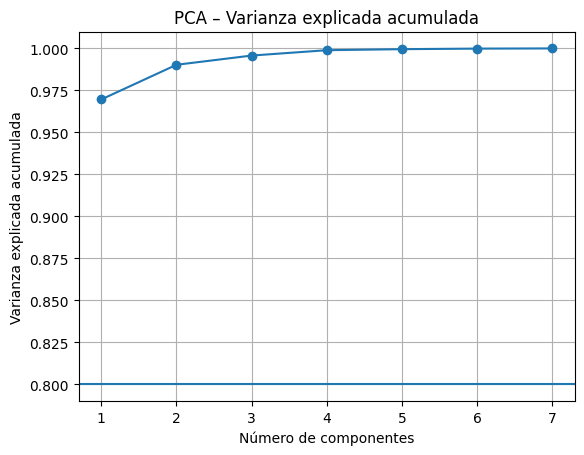

In [7]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada
explained_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure()
plt.plot(range(1, len(explained_var)+1), explained_var, marker="o")
plt.axhline(y=0.8)
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA – Varianza explicada acumulada")
plt.grid(True)
plt.show()


In [8]:
pca2 = PCA(n_components=2)
X_pca_2 = pca2.fit_transform(X_scaled)

df_pca = pd.DataFrame(
    X_pca_2,
    columns=["PC1", "PC2"],
    index=X.index
)

display(df_pca.head())


,PC1,PC2
DPTO_HECHO_NEW,,
AMAZONAS,-1.087390,-0.002212
ANCASH,-0.338237,-0.114408
APURIMAC,-1.076479,-0.103830
AREQUIPA,0.636901,-0.818107
AYACUCHO,-0.919029,-0.077092


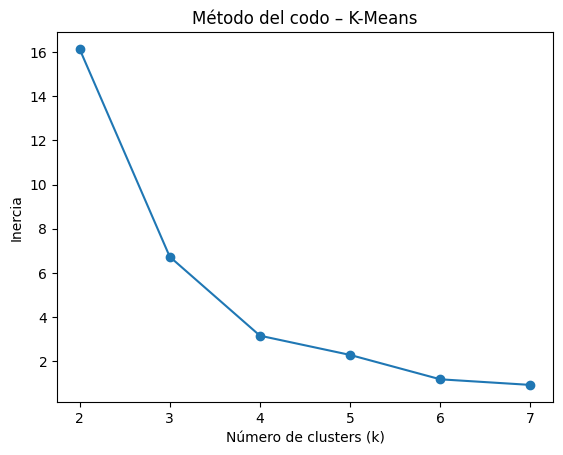

In [9]:
from sklearn.cluster import KMeans

inertia = []

K = range(2, 8)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_pca_2)
    inertia.append(km.inertia_)

plt.figure()
plt.plot(K, inertia, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del codo – K-Means")
plt.show()


In [10]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca_2)

df_pca["Cluster"] = clusters
display(df_pca.sort_values("Cluster"))


,PC1,PC2,Cluster
DPTO_HECHO_NEW,,,
ANCASH,-0.338237,-0.114408,0
AREQUIPA,0.636901,-0.818107,0
CUSCO,-0.192790,-0.415122,0
ICA,-0.052161,-0.013092,0
LAMBAYEQUE,0.443649,-0.418069,0
LA LIBERTAD,1.336360,1.463157,0
JUNIN,-0.145782,-0.327187,0
PROV. CONST. DEL CALLAO,0.291869,0.287325,0
PIURA,0.648506,0.412941,0


Los notebooks de Colab ejecutan código en los servidores alojados en la nube de Google, lo que significa que puedes aprovechar al máximo el hardware de Google, incluidas las <a href="#using-accelerated-hardware">GPU y TPU</a>, independientemente de la potencia de tu máquina. Lo único que necesitas es un navegador.

Por ejemplo, si estás esperando que el código de <strong>pandas</strong> termine de ejecutarse y quieres ir más rápido, puedes cambiar a un entorno de ejecución de GPU y usar bibliotecas como <a href="https://rapids.ai/cudf-pandas">RAPIDS cuDF</a> que proporcionan aceleración sin cambios de código.

Para obtener más información sobre la aceleración de pandas en Colab, consulta la <a href="https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb">guía de 10 minutos</a> o
 la <a href="https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb">demostración sobre el análisis de datos del mercado de valores de EE.UU.</a>.

<div class="markdown-google-sans">

## Aprendizaje automático
</div>

Colab te permite importar un conjunto de datos de imágenes, entrenar un clasificador de imágenes en él y evaluar el modelo con solo <a href="https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb">unas pocas líneas de código</a>.

Entre los usos que se la da a Colab en la comunidad de aprendizaje automático, se encuentran los siguientes:
- Introducción a TensorFlow
- Desarrollo y entrenamiento de redes neuronales
- Experimentación con TPU
- Diseminación de investigación de IA
- Creación de instructivos

Para ver notebooks de Colab de ejemplo que muestran los usos del aprendizaje automático, consulta los <a href="#machine-learning-examples">ejemplos</a> que se incluyen a continuación.

<div class="markdown-google-sans">

## Más recursos

### Cómo trabajar con notebooks en Colab

</div>

- [Descripción general de Colab](/notebooks/basic_features_overview.ipynb)
- [Guía para usar Markdown](/notebooks/markdown_guide.ipynb)
- [Cómo importar bibliotecas y luego instalar dependencias](/notebooks/snippets/importing_libraries.ipynb)
- [Cómo guardar y cargar notebooks en GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Formularios interactivos](/notebooks/forms.ipynb)
- [Widgets interactivos](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Cómo trabajar con datos
</div>

- [Cómo cargar datos: Drive, Hojas de cálculo y Google Cloud Storage](/notebooks/io.ipynb)
- [Gráficos: visualización de datos](/notebooks/charts.ipynb)
- [Cómo comenzar a usar BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Aprendizaje automático

<div>

Estos son algunos de los notebooks relacionados con el aprendizaje automático; incluido el curso de aprendizaje automático en línea de Google. Para obtener más información, consulta el <a href="https://developers.google.com/machine-learning/crash-course/">sitio web del curso completo</a>.
- [Introducción a Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Introducción a RAPIDS cuDF para acelerar Pandas](https://nvda.ws/rapids-cudf)
- [Comenzar a usar el modo de acelerador de cuML](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)
- [Regresión lineal con tf.keras usando datos sintéticos](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/linear_regression_with_synthetic_data.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Uso de aceleración de hardware
</div>

- [TensorFlow con GPU](/notebooks/gpu.ipynb)
- [TPU en Colab](/notebooks/tpu.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Ejemplos destacados

</div>

- <a href="https://tensorflow.org/hub/tutorials/tf2_image_retraining">Reentrenamiento de un clasificador de imágenes</a>: compila un modelo de Keras sobre un clasificador de imágenes previamente entrenado para distinguir flores.
- <a href="https://tensorflow.org/hub/tutorials/tf2_text_classification">Clasificación de texto</a>: clasifica opiniones sobre películas de IMDB como <em>positivas</em> o <em>negativas</em>.
- <a href="https://tensorflow.org/hub/tutorials/tf2_arbitrary_image_stylization">Transferencia de estilos</a>: usa el aprendizaje profundo para transferir el estilo de una imagen a otra.
- <a href="https://tensorflow.org/hub/tutorials/retrieval_with_tf_hub_universal_encoder_qa">Codificador universal de oraciones en varios idiomas para preguntas y respuestas</a>: usa un modelo de aprendizaje automático para responder preguntas del conjunto de datos SQuAD.
- <a href="https://tensorflow.org/hub/tutorials/tweening_conv3d">Interpolación de videos</a>: predice lo que sucedió en un video entre el primer y el último fotograma.
